In [13]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# import common_code/PostProcessingScripts which contains default python code used in this jupyter notebook (such as plotting etc.)
sys.path.append('/Users/floorbroekgaarden/Projects/GitHub/common_code/.')
# from PostProcessingScripts import * 


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt




In [14]:
data_folder = '/Users/floorbroekgaarden/Projects/GitHub/common-envelope-efficiency/data/'
plotting_folder = '/Users/floorbroekgaarden/Projects/GitHub/common-envelope-efficiency/plotting-code/'
figure_folder = '/Users/floorbroekgaarden/Projects/GitHub/common-envelope-efficiency/figure_files/'


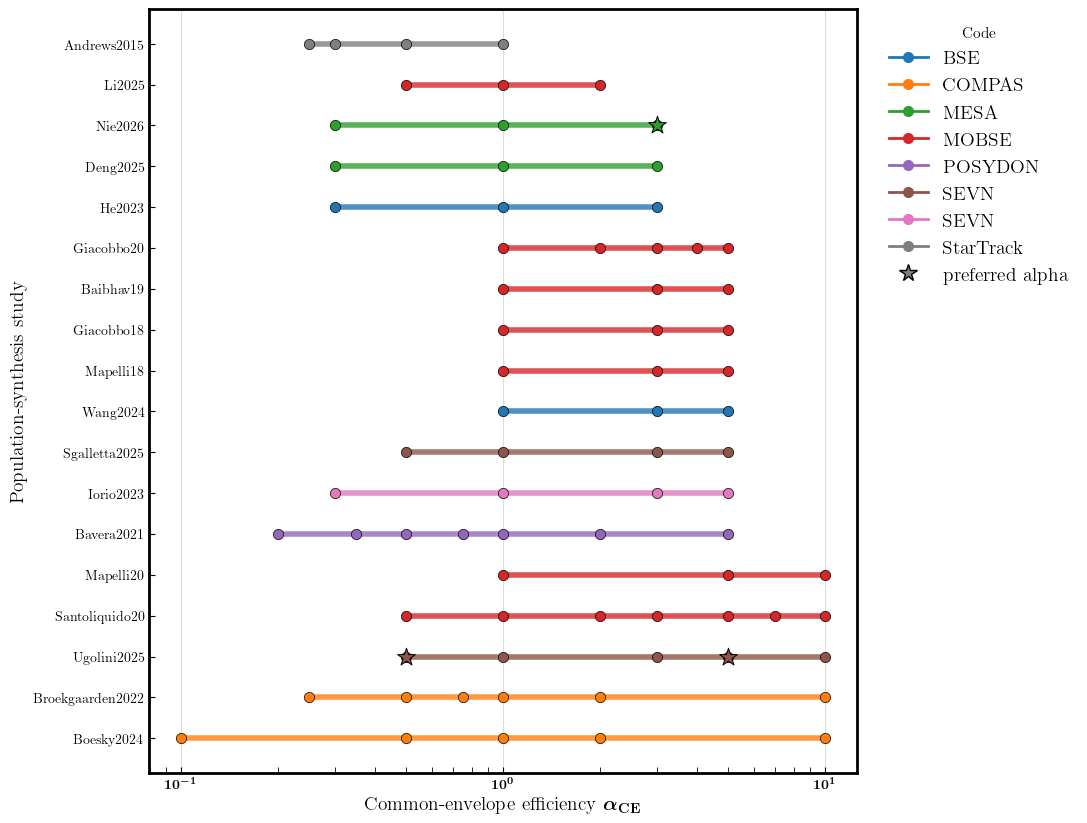

In [19]:


ce_file = os.path.join(data_folder, "ce-data-pop-synth.csv")
specs_file = os.path.join(data_folder, "pop-synth-specs.csv")

# -------------------------
# Read data
# -------------------------
df_alpha = pd.read_csv(ce_file)
df_specs = pd.read_csv(specs_file)

df_alpha.columns = df_alpha.columns.str.strip()
df_specs.columns = df_specs.columns.str.strip()

alpha_cols = [c for c in df_alpha.columns if c != "label"]

# Convert to numeric
for c in alpha_cols:
    df_alpha[c] = pd.to_numeric(df_alpha[c], errors="coerce")

for c in ["preferred alpha 1", "preferred alpha 2"]:
    if c in df_specs.columns:
        df_specs[c] = pd.to_numeric(df_specs[c], errors="coerce")

# Merge
df = df_alpha.merge(
    df_specs[["label", "code", "preferred alpha 1", "preferred alpha 2"]],
    on="label",
    how="left"
)

# -------------------------
# Compute range and sort
# -------------------------
df["alpha_min"] = df[alpha_cols].min(axis=1)
df["alpha_max"] = df[alpha_cols].max(axis=1)
df["alpha_range"] = df["alpha_max"] - df["alpha_min"]

# Remove invalid (<=0) values for log plotting
def clean_alpha(row):
    vals = row[alpha_cols].values.astype(float)
    return vals[vals > 0]

df["alpha_values"] = df.apply(clean_alpha, axis=1)

# Sort by range (largest range on top)
df = df.sort_values("alpha_range", ascending=False).reset_index(drop=True)

ypos = np.arange(len(df))

# -------------------------
# Colors by code
# -------------------------
codes = sorted(df["code"].dropna().unique())
cmap = plt.get_cmap("tab10")
code_colors = {code: cmap(i % 10) for i, code in enumerate(codes)}

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(11, 0.38 * len(df) + 1.5))

for i, row in df.iterrows():
    code = row["code"]
    color = code_colors.get(code, "gray")

    alpha_values = row["alpha_values"]

    if len(alpha_values) == 0:
        continue

    # Range line
    ax.plot(
        [np.min(alpha_values), np.max(alpha_values)],
        [i, i],
        color=color,
        lw=4,
        alpha=0.8,
        zorder=1
    )

    # Scatter points
    ax.scatter(
        alpha_values,
        np.full_like(alpha_values, i, dtype=float),
        color=color,
        s=55,
        edgecolor="k",
        linewidth=0.5,
        zorder=2
    )

    # Preferred alpha (stars)
    preferred_values = []
    for pref_col in ["preferred alpha 1", "preferred alpha 2"]:
        val = row.get(pref_col, np.nan)
        if pd.notna(val) and val > 0:
            preferred_values.append(float(val))

    if preferred_values:
        ax.scatter(
            preferred_values,
            np.full(len(preferred_values), i),
            marker="*",
            s=180,
            color=color,
            edgecolor="k",
            linewidth=0.7,
            zorder=3
        )

# -------------------------
# Formatting
# -------------------------
ax.set_yticks(ypos)
ax.set_yticklabels(df["label"], fontsize=11)   # larger labels

ax.set_xlabel(r"Common-envelope efficiency $\alpha_{\rm CE}$", fontsize=14)
ax.set_ylabel("Population-synthesis study", fontsize=14)

# Log-scale x-axis
ax.set_xscale("log")

# Tick styling
ax.tick_params(
    axis="both",
    which="both",
    direction="in",
    labelsize=12,
    length=5
)

# Grid
ax.grid(axis="x", alpha=0.45)
ax.set_axisbelow(True)

# Legend
handles = [
    plt.Line2D([0], [0],
               marker="o",
               color=code_colors[code],
               label=code,
               markersize=7,
               lw=2)
    for code in codes
]

handles.append(
    plt.Line2D([0], [0],
               marker="*",
               color="gray",
               markeredgecolor="k",
               label="preferred alpha",
               markersize=13,
               lw=0)
)

ax.legend(
    handles=handles,
    title="Code",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=14,
    title_fontsize=11
)

plt.tight_layout()

# Save
save_path = os.path.join(figure_folder, "alpha_CE_values_by_study_log_sorted.pdf")
plt.savefig(save_path, bbox_inches="tight")

plt.show()

